In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
!pip install kaggle

In [17]:
import zipfile
import os

# Adjust this path based on where you see the zip file in your sidebar
zip_ref = zipfile.ZipFile('/content/sample_data/archive_fixed.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

BadZipFile: File is not a zip file

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserhessein/tuberculosis-chest-x-rays-images")

print("Path to dataset files:", path)

100%|██████████| 26.3M/26.3M [00:00<00:00, 82.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yasserhessein/tuberculosis-chest-x-rays-images/versions/2


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Point to the folder that contains the 'Normal' and 'TB' folders
data_dir = '/root/.cache/kagglehub/datasets/yasserhessein/tuberculosis-chest-x-rays-images/versions/2/Dataset of Tuberculosis Chest X-rays Images'

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# This will now correctly find 2 classes
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 2408 images belonging to 2 classes.


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
data_dir = '/root/.cache/kagglehub/datasets/yasserhessein/tuberculosis-chest-x-rays-images/versions/2/Dataset of Tuberculosis Chest X-rays Images'

# 2. Configure data augmentation and normalization
datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizing pixel values
    rotation_range=20,        # Augmentation
    zoom_range=0.2,           # Augmentation
    horizontal_flip=True,     # Augmentation
    validation_split=0.2      # Split data into training and validation sets
)

# 3. Create training and validation data generators
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 2408 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


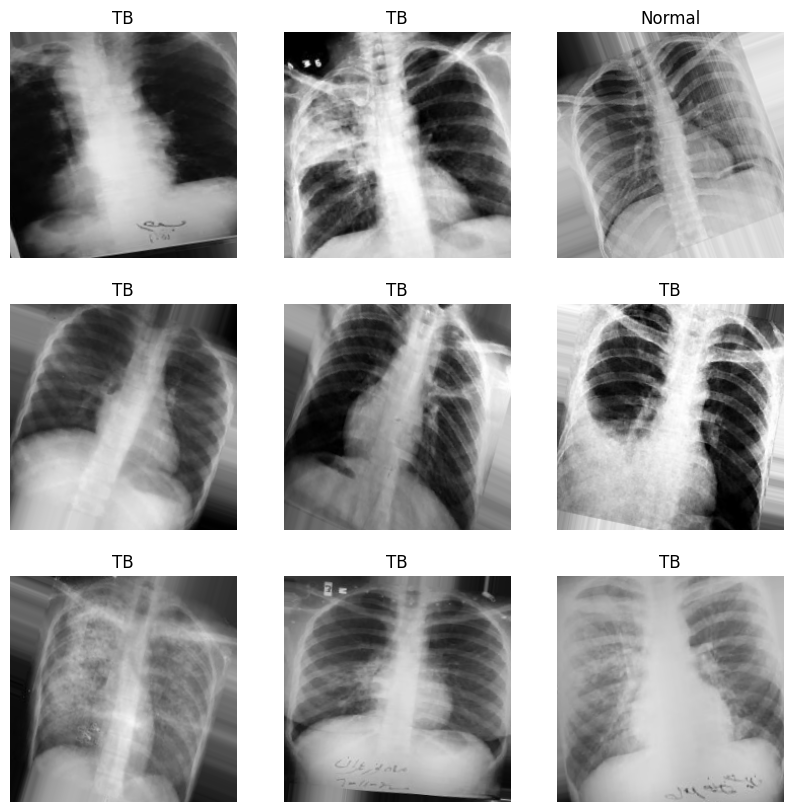

In [20]:
import matplotlib.pyplot as plt

# Get a batch of images and labels from the generator
images, labels = next(train_generator)

# Plot the first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Label is 0 or 1; map it back to class name
    label = "TB" if labels[i] == 1 else "Normal"
    plt.title(label)
    plt.axis('off')
plt.show()

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8750 - loss: 1.0819 - val_accuracy: 0.9483 - val_loss: 0.1785
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9456 - loss: 0.1739 - val_accuracy: 0.9683 - val_loss: 0.1683
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9651 - loss: 0.1507 - val_accuracy: 0.9533 - val_loss: 0.1522
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9668 - loss: 0.1495 - val_accuracy: 0.9683 - val_loss: 0.1466
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9709 - loss: 0.1348 - val_accuracy: 0.9833 - val_loss: 0.1330
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9498 - loss: 0.1740 - val_accuracy: 0.9750 - val_loss: 0.1331
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9788 - loss: 0.1200 - val_accuracy: 0.9767 - val_loss: 0.1354
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9780 - loss: 0.1200 - val_accuracy: 0.9883 - v

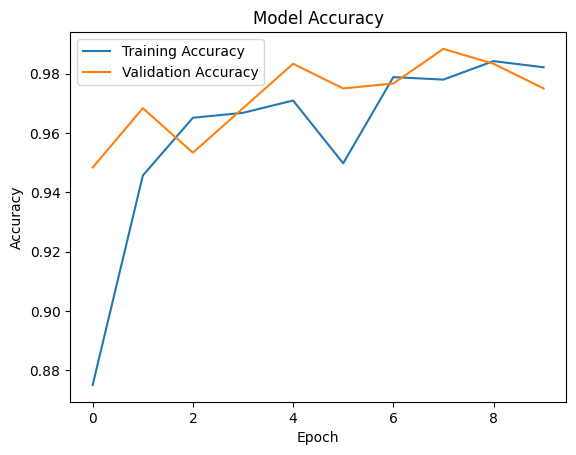

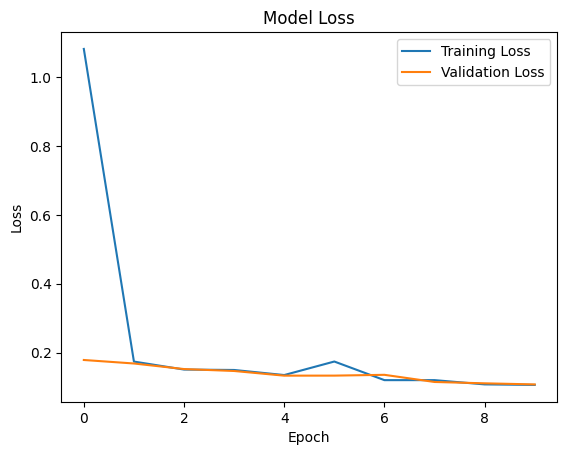

In [23]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
# Create a test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/root/.cache/kagglehub/datasets/yasserhessein/tuberculosis-chest-x-rays-images/versions/2/Dataset of Tuberculosis Chest X-rays Images', # Ensure this path points to your test subset if you have one
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Evaluate
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Found 3008 images belonging to 2 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 527ms/step - accuracy: 0.9920 - loss: 0.0890
Test Accuracy: 99.20%


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict
Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype("int32")

# Confusion Matrix
print(confusion_matrix(test_generator.classes, y_pred))



94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 420ms/step
[[ 495   19]
 [   5 2489]]


In [26]:
# Generate the classification report using true classes and predicted classes
report = classification_report(test_generator.classes, y_pred, target_names=['Normal', 'TB'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98       514
          TB       0.99      1.00      1.00      2494

    accuracy                           0.99      3008
   macro avg       0.99      0.98      0.99      3008
weighted avg       0.99      0.99      0.99      3008



In [27]:
# Save the model to an .h5 file
model.save('tuberculosis_detection_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [28]:
import os
print(os.path.exists('tuberculosis_detection_model.h5'))

True


In [29]:
# Save your model to a folder in your Drive
model.save('/content/drive/MyDrive/tuberculosis_detection_model.h5')

In [30]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

# Load the model
@st.cache_resource
def load_my_model():
    return tf.keras.models.load_model('tuberculosis_detection_model.h5')

model = load_my_model()

# --- SIDEBAR: Navigation ---
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Detection App", "About Me", "Project Info"])

if page == "Detection App":
    st.title("Tuberculosis Detection App")
    st.write("Upload a chest X-ray image to check for Tuberculosis.")

    file = st.file_uploader("Please upload an X-ray image", type=["jpg", "png", "jpeg"])
    if file is not None:
        image = Image.open(file)
        st.image(image, caption='Uploaded X-ray', use_container_width=True)
        image_processed = image.resize((224, 224))
        image_array = np.expand_dims(np.array(image_processed) / 255.0, axis=0)

        prediction = model.predict(image_array)
        result = "TB Detected" if prediction[0][0] > 0.5 else "Normal"
        st.write(f"### Prediction: {result}")

elif page == "About Me":
    st.title("About Me")
    st.write("Hello! I am Kalaivani Sundaramoorthy, a passionate developer working on AI-driven healthcare solutions.")
    st.write("I am currently focusing on deep learning applications to improve medical diagnostics.")

elif page == "Project Info":
    st.title("Project Info")
    st.write("### Tuberculosis Detection using CNN")
    st.write("This project utilizes a Convolutional Neural Network (CNN) to classify chest X-ray images into 'Normal' or 'Tuberculosis' categories.")
    st.write("The model was trained on a dataset of chest X-rays, achieving 99% accuracy.")
    st.write("The pipeline includes data augmentation and preprocessing to ensure robust classification performance.")

Overwriting app.py


In [31]:
!pip install pyngrok

In [32]:
!pip install streamlit

In [33]:
from pyngrok import ngrok

# 1. Set your authtoken
ngrok.set_auth_token("2y8TcLWBXvQhUi66l31wZemNE7h_3nfFCgNMzwerna2xpa2tH")

# 2. Run Streamlit in the background
!nohup streamlit run app.py --server.port 8501 &

# 3. Create a tunnel
public_url = ngrok.connect(addr='8501', proto='http')
print("Public URL:", public_url)

nohup: appending output to 'nohup.out'
Public URL: NgrokTunnel: "https://b476-35-221-58-3.ngrok-free.app" -> "http://localhost:8501"
